In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [128]:
df= pd.read_csv('/content/credit_risk_dataset.csv')
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


Data Inspection

In [129]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


**Handling Missing and Unrealistic values**

In [131]:
df['person_emp_length'].describe()

,person_emp_length
count,31686.000000
mean,4.789686
std,4.142630
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,123.000000


In [132]:
df.loc[df['person_emp_length']>7].sort_values(by='person_emp_length', ascending=False).head(20)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4
32355,78,48000,RENT,41.0,MEDICAL,A,3000,7.51,0,0.06,N,25
32515,53,106000,MORTGAGE,38.0,PERSONAL,B,20000,9.88,0,0.19,N,23
32428,58,49000,MORTGAGE,34.0,MEDICAL,D,7500,13.55,1,0.15,Y,24
30914,48,70000,MORTGAGE,31.0,HOMEIMPROVEMENT,D,9000,14.54,0,0.13,N,17
32263,46,180000,MORTGAGE,31.0,MEDICAL,B,18000,9.91,0,0.10,N,12
31867,46,180000,MORTGAGE,31.0,VENTURE,B,18000,9.91,0,0.10,N,11
31866,47,178000,OWN,31.0,VENTURE,B,9000,10.99,0,0.05,N,17
32562,61,160000,MORTGAGE,30.0,PERSONAL,B,24000,10.38,0,0.15,N,21


In [133]:
df['person_emp_length'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 32581 entries, 0 to 32580
Series name: person_emp_length
Non-Null Count  Dtype  
--------------  -----  
31686 non-null  float64
dtypes: float64(1)
memory usage: 254.7 KB


In [134]:
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace= True)

/tmp/ipython-input-663/1027344598.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace= True)


In [135]:
idx= np.where(df['person_emp_length'].isnull())
len(idx[0])

0

In [136]:
df.loc[df['person_age'] - df['person_emp_length'] < 16]
# np.where(df['person_income'] <10000 and df['person_emp_length'] >= 12)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3
18,23,113000,RENT,8.0,DEBTCONSOLIDATION,D,35000,18.25,1,0.31,N,4
65,22,12000,MORTGAGE,7.0,EDUCATION,D,1500,14.84,0,0.13,Y,3
68,24,255000,MORTGAGE,9.0,EDUCATION,A,9600,6.99,0,0.04,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
31867,46,180000,MORTGAGE,31.0,VENTURE,B,18000,9.91,0,0.10,N,11
32206,40,66000,OWN,25.0,PERSONAL,C,6125,14.65,0,0.09,N,13
32263,46,180000,MORTGAGE,31.0,MEDICAL,B,18000,9.91,0,0.10,N,12
32286,36,48686,RENT,21.0,MEDICAL,D,12000,13.99,0,0.25,N,13


In [158]:
idx= np.where(df['person_age'] - df['person_emp_length'] < 16)[0]
print(len(idx))
df1= df.drop(idx, axis=0)

740


In [146]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31841 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  31841 non-null  int64  
 1   person_income               31841 non-null  int64  
 2   person_home_ownership       31841 non-null  object 
 3   person_emp_length           31841 non-null  float64
 4   loan_intent                 31841 non-null  object 
 5   loan_grade                  31841 non-null  object 
 6   loan_amnt                   31841 non-null  int64  
 7   loan_int_rate               28804 non-null  float64
 8   loan_status                 31841 non-null  int64  
 9   loan_percent_income         31841 non-null  float64
 10  cb_person_default_on_file   31841 non-null  object 
 11  cb_person_cred_hist_length  31841 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.2+ MB


In [126]:
df1

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


<Axes: xlabel='loan_grade', ylabel='loan_int_rate'>

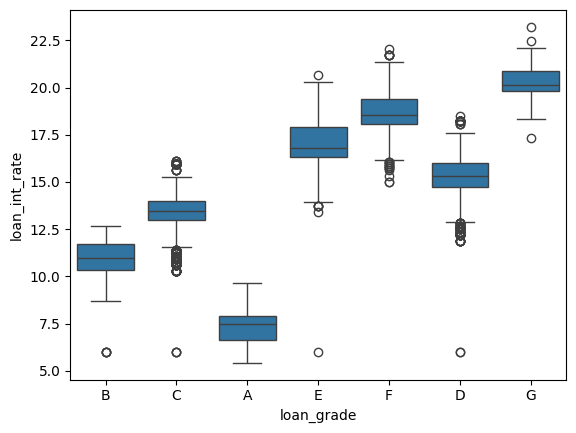

In [139]:
sns.boxplot(data=df1, x='loan_grade', y= 'loan_int_rate')

In [159]:
df1['loan_int_rate']= df1['loan_int_rate'].fillna(df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.median()))

In [160]:
df1['loan_int_rate'].info()

<class 'pandas.core.series.Series'>
Index: 31841 entries, 1 to 32580
Series name: loan_int_rate
Non-Null Count  Dtype  
--------------  -----  
31841 non-null  float64
dtypes: float64(1)
memory usage: 497.5 KB


In [164]:
df1.loc[df['loan_int_rate'].isnull()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
39,23,71500,RENT,3.0,DEBTCONSOLIDATION,D,30000,15.31,1,0.42,N,4
50,24,78000,RENT,4.0,DEBTCONSOLIDATION,D,30000,15.31,1,0.38,Y,4
57,23,277000,OWN,3.0,PERSONAL,A,35000,7.49,0,0.13,N,4
59,24,12000,OWN,2.0,VENTURE,E,1750,16.82,0,0.15,Y,3
62,26,263000,MORTGAGE,0.0,EDUCATION,B,10000,10.99,1,0.04,N,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32547,53,4888,OWN,0.0,VENTURE,C,1400,13.48,1,0.29,Y,28
32552,65,45900,RENT,2.0,EDUCATION,C,10000,13.48,0,0.22,Y,19
32553,54,20000,RENT,2.0,MEDICAL,C,5000,13.48,0,0.25,N,28
32569,51,60000,MORTGAGE,1.0,PERSONAL,A,7500,7.49,0,0.13,N,23


**Checking for Class Imbalance**

In [165]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31841 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  31841 non-null  int64  
 1   person_income               31841 non-null  int64  
 2   person_home_ownership       31841 non-null  object 
 3   person_emp_length           31841 non-null  float64
 4   loan_intent                 31841 non-null  object 
 5   loan_grade                  31841 non-null  object 
 6   loan_amnt                   31841 non-null  int64  
 7   loan_int_rate               31841 non-null  float64
 8   loan_status                 31841 non-null  int64  
 9   loan_percent_income         31841 non-null  float64
 10  cb_person_default_on_file   31841 non-null  object 
 11  cb_person_cred_hist_length  31841 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.2+ MB


In [169]:
df1['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
0,0.781477
1,0.218523


In [175]:
df1['person_home_ownership'].value_counts()

,count
person_home_ownership,
RENT,16149
MORTGAGE,13072
OWN,2514
OTHER,106


In [205]:
idx= df1.loc[df1['person_home_ownership'] == 'OTHER'].index
print(idx)
df2= df1.drop(idx, axis=0)

Index([   29,   566,   715,   880,  1308,  1503,  1527,  1638,  1818,  2351,
       ...
       30304, 30875, 30895, 31085, 31297, 31443, 31915, 32136, 32197, 32291],
      dtype='int64', length=106)


In [206]:
df2['loan_intent'].value_counts()

,count
loan_intent,
EDUCATION,6249
MEDICAL,5930
VENTURE,5556
PERSONAL,5393
DEBTCONSOLIDATION,5077
HOMEIMPROVEMENT,3530


In [207]:
df2['loan_grade'].value_counts()

,count
loan_grade,
A,10484
B,10184
C,6311
D,3528
E,934
F,234
G,60


In [210]:
df2['cb_person_default_on_file'].value_counts(normalize=True)

,proportion
cb_person_default_on_file,
N,0.82357
Y,0.17643


**Outliers Detection and Removal**

In [214]:
df2.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31735.000000,3.173500e+04,31735.000000,31735.000000,31735.000000,31735.000000,31735.000000,31735.000000
mean,27.805609,6.599917e+04,4.646668,9565.231605,11.014213,0.218213,0.169977,5.842760
std,6.381033,6.233291e+04,3.910816,6324.423727,3.211014,0.413040,0.106752,4.075682
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.840000e+04,2.000000,5000.000000,7.880000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.905000e+04,7.000000,12000.000000,13.480000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [224]:
idx= df2.loc[df2['person_age']>94].index
df3= df2.drop(idx, axis=0)

In [235]:
df3['person_income'].describe().astype(int)

,person_income
count,31730
mean,65801
std,52673
min,4000
25%,38400
50%,55000
75%,79037
max,2039784


**Data Visualization**

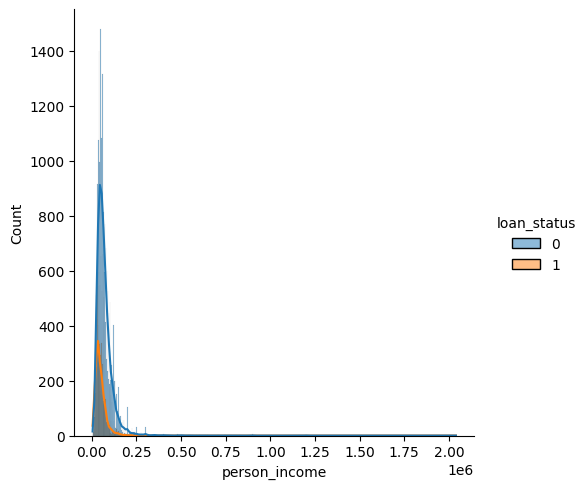

In [242]:
sns.displot(data=df3, x='person_income', hue='loan_status', kde=True)

<Axes: >

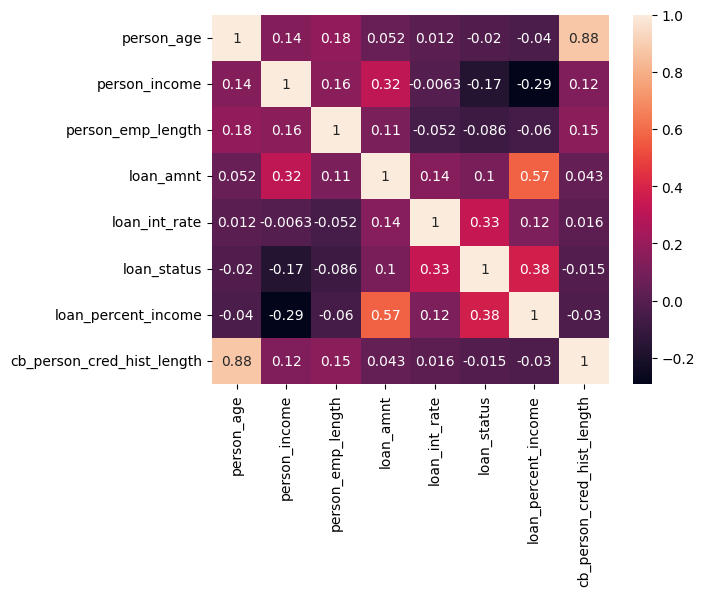

In [246]:
sns.heatmap(df3.corr(numeric_only=True), annot=True)

**Encoding Categorical Variables**